In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

In [23]:
# Download S&P 500 front month futures data
sp500_futures_prices = yf.download("ES=F")["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed


In [24]:
sp500_futures_prices.head()

Date
2026-04-14    7004.75
2026-04-15    7060.50
2026-04-16    7077.00
2026-04-17    7161.50
2026-04-20    7148.00
Name: ES=F, dtype: float64

In [25]:
# Calculate logarithmic returns
log_returns = np.log(sp500_futures_prices).diff()

In [26]:
log_returns.head()

Date
2026-04-14         NaN
2026-04-15    0.007927
2026-04-16    0.002334
2026-04-17    0.011869
2026-04-20   -0.001887
Name: ES=F, dtype: float64

In [27]:
# Calculate cumulative returns
cumulative_returns = np.exp(log_returns.cumsum())

In [28]:
# Calculate ongoing drawdown
rolling_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns - rolling_max) / rolling_max

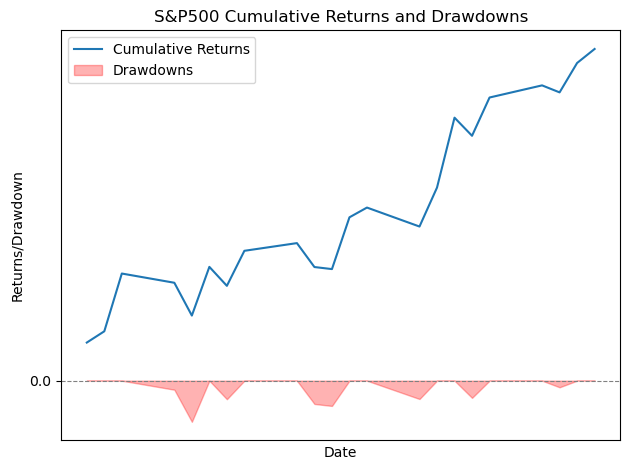

In [29]:
# Create figure and axis objects
fig, ax = plt.subplots()
# Plotting the results
ax.plot(cumulative_returns - 1, label="Cumulative Returns")
ax.fill_between(drawdowns.index, drawdowns, label="Drawdowns", color="red", alpha=0.3)
# Setting x-axis major locator to each year and formatter
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
# Setting y-axis ticks every 20%
ax.yaxis.set_major_locator(MultipleLocator(0.2))
# Adding grid with vertical lines for each year
ax.grid(True, which="major", linestyle="--", color="grey")
# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45)
# Ensure date labels are visible
ax.legend()
ax.set_title("S&P500 Cumulative Returns and Drawdowns")
ax.set_xlabel("Date")
ax.set_ylabel("Returns/Drawdown")
fig.tight_layout()
plt.show()